In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data_high=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Multimodal68\FreqDescriptor-Multimodal68.xlsx')
data_low=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Batch633\FreqDescriptor-Batch633.xlsx')

In [3]:
data_high

,ID,Original_SMILES,zpe_ha,gcorr_ha,alpha_iso_bohr3,s_vib_cal_molk,svib_frac
0,1,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,1.256693,1.118353,1203.29,367.673,0.798433
1,2,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,1.370434,1.226119,1229.62,392.510,0.808569
2,3,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,0.835982,0.738739,778.95,227.803,0.721329
3,4,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,0.807205,0.714405,747.58,210.575,0.707787
4,5,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,1.053819,0.942397,913.08,278.634,0.758109
...,...,...,...,...,...,...,...
63,64,O=C(C(C=C1Cl)=C(C=C1Cl)C/2=C(C#N)/C#N)C2=C/C3=...,0.628415,0.538802,700.11,197.889,0.693484
64,65,O=C(C1=C2C=C(F)C(F)=C1)C(/C2=C(C#N)\C#N)=C\C3=...,0.631320,0.543313,670.98,193.340,0.689473
65,66,O=C(C(C=C1Cl)=C(C=C1Cl)C/2=C(C#N)/C#N)C2=C/C3=...,0.808734,0.703170,860.13,251.641,0.737762
66,67,O=C(C1=C2C=C(F)C(F)=C1)C(/C2=C(C#N)\C#N)=C\C3=...,0.811591,0.707588,827.09,247.199,0.735138


In [4]:
properties = ['zpe_ha', 'gcorr_ha', 'alpha_iso_bohr3', 's_vib_cal_molk', 'svib_frac']

cols_needed = ['ID'] + properties

data_high = data_high[cols_needed]
data_low = data_low[cols_needed]

# === 按 ID 合并（inner 保证只有 68 个重叠分子）===
df = pd.merge(
    data_high, data_low,
    on='ID',
    suffixes=('_high', '_low'),
    how='inner'
)

print(f"Number of matched molecules: {len(df)}")

Number of matched molecules: 68


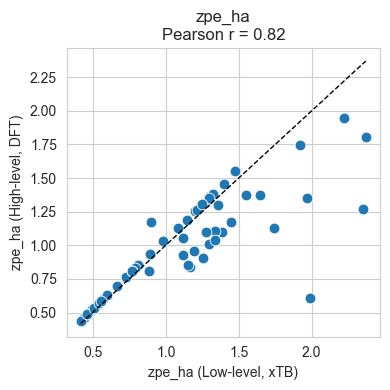

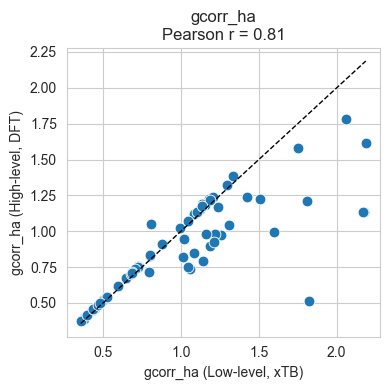

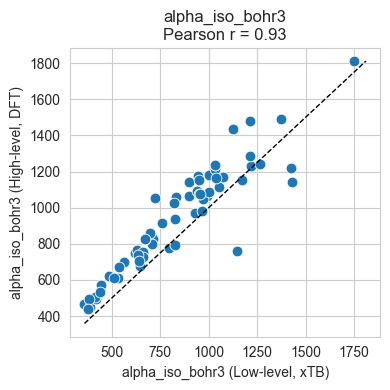

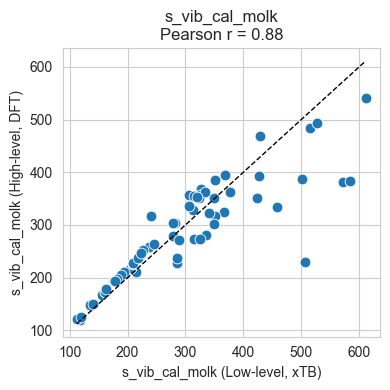

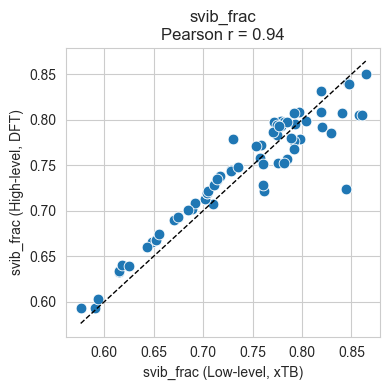

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sns.set_style("whitegrid")

for prop in properties:
    x = df[f'{prop}_low']
    y = df[f'{prop}_high']
    
    r, _ = pearsonr(x, y)

    plt.figure(figsize=(4, 4))
    sns.scatterplot(x=x, y=y, s=60)
    
    # 1:1 line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)

    plt.xlabel(f'{prop} (Low-level, xTB)')
    plt.ylabel(f'{prop} (High-level, DFT)')
    plt.title(f'{prop}\nPearson r = {r:.2f}')
    plt.tight_layout()
    plt.show()


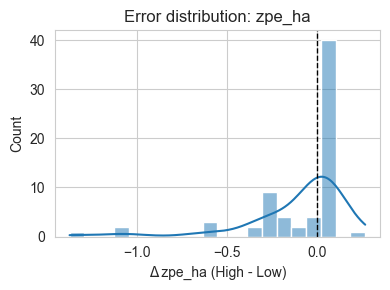

zpe_ha: mean Δ = -0.109, std Δ = 0.292, MAE = 0.168


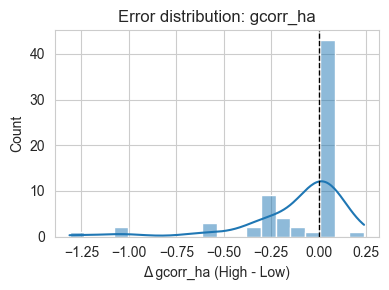

gcorr_ha: mean Δ = -0.115, std Δ = 0.278, MAE = 0.157


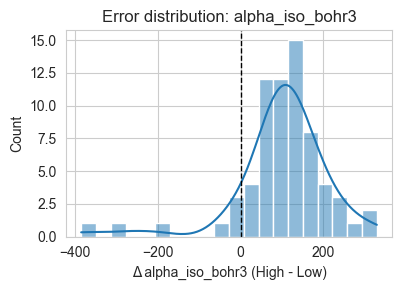

alpha_iso_bohr3: mean Δ = 99.642, std Δ = 112.390, MAE = 128.229


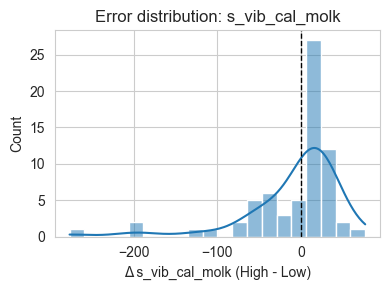

s_vib_cal_molk: mean Δ = -9.108, std Δ = 59.578, MAE = 37.395


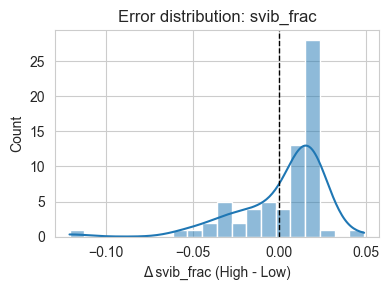

svib_frac: mean Δ = 0.002, std Δ = 0.026, MAE = 0.020


In [6]:
for prop in properties:
    df[f'delta_{prop}'] = df[f'{prop}_high'] - df[f'{prop}_low']

    # ===== 统计量 =====
    mean_delta = df[f'delta_{prop}'].mean()
    std_delta = df[f'delta_{prop}'].std()
    mae = df[f'delta_{prop}'].abs().mean()   # ← MAE

    # ===== 画分布 =====
    plt.figure(figsize=(4, 3))
    sns.histplot(df[f'delta_{prop}'], bins=20, kde=True)
    plt.axvline(0, color='k', linestyle='--', lw=1)
    
    plt.xlabel(f'Δ {prop} (High - Low)')
    plt.title(f'Error distribution: {prop}')
    plt.tight_layout()
    plt.show()

    # ===== 打印 =====
    print(
        f"{prop}: mean Δ = {mean_delta:.3f}, "
        f"std Δ = {std_delta:.3f}, "
        f"MAE = {mae:.3f}"
    )

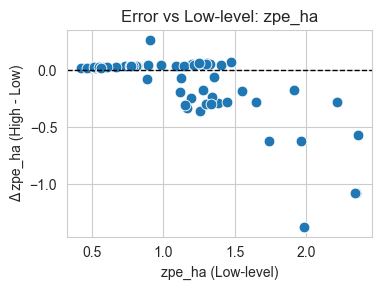

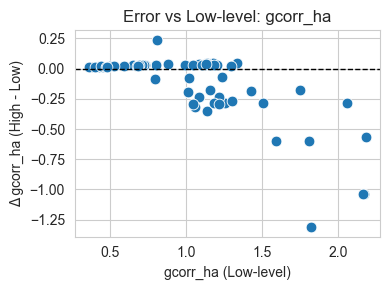

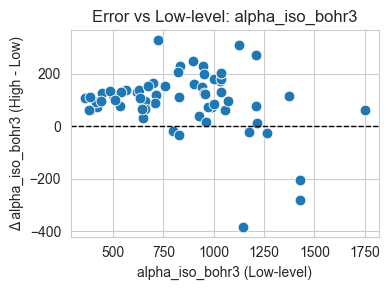

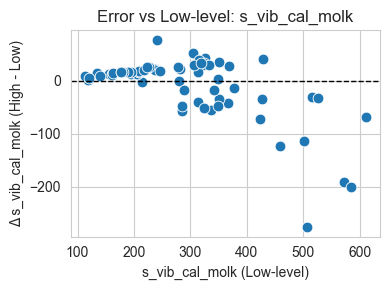

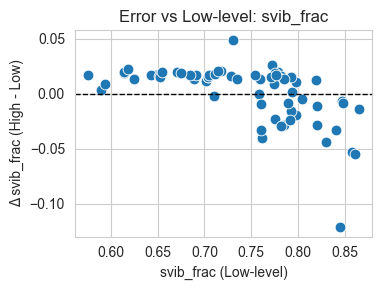

In [7]:
for prop in properties:
    plt.figure(figsize=(4, 3))
    sns.scatterplot(
        x=df[f'{prop}_low'],
        y=df[f'delta_{prop}'],
        s=60
    )
    plt.axhline(0, color='k', linestyle='--', lw=1)

    plt.xlabel(f'{prop} (Low-level)')
    plt.ylabel(f'Δ {prop} (High - Low)')
    plt.title(f'Error vs Low-level: {prop}')
    plt.tight_layout()
    plt.show()


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.linear_model import LinearRegression

for prop in properties:
    X = df[[f'{prop}_low']].values
    y = df[f'{prop}_high'].values

    lr = LinearRegression().fit(X, y)
    y_pred = lr.predict(X)

    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)   # 不用 squared 参数
    rmse = np.sqrt(mse)

    print(f'\n{prop}')
    print(f'  y = {lr.coef_[0]:.3f} * x + {lr.intercept_:.3f}')
    print(f'  MAE = {mae:.3f}, RMSE = {rmse:.3f}')



zpe_ha
  y = 0.576 * x + 0.360
  MAE = 0.146, RMSE = 0.200

gcorr_ha
  y = 0.564 * x + 0.321
  MAE = 0.137, RMSE = 0.188

alpha_iso_bohr3
  y = 0.909 * x + 174.794
  MAE = 72.968, RMSE = 108.321

s_vib_cal_molk
  y = 0.686 * x + 81.601
  MAE = 33.243, RMSE = 45.319

svib_frac
  y = 0.800 * x + 0.150
  MAE = 0.015, RMSE = 0.021


### 1. zpe_ha

In [9]:
df

,ID,zpe_ha_high,gcorr_ha_high,alpha_iso_bohr3_high,s_vib_cal_molk_high,svib_frac_high,zpe_ha_low,gcorr_ha_low,alpha_iso_bohr3_low,s_vib_cal_molk_low,svib_frac_low,delta_zpe_ha,delta_gcorr_ha,delta_alpha_iso_bohr3,delta_s_vib_cal_molk,delta_svib_frac
0,1,1.256693,1.118353,1203.29,367.673,0.798433,1.197931,1.083069,1030.945172,326.080,0.778814,0.058762,0.035284,172.344828,41.593,0.019619
1,2,1.370434,1.226119,1229.62,392.510,0.808569,1.647717,1.507564,1217.200360,426.861,0.819664,-0.277283,-0.281445,12.419640,-34.351,-0.011095
2,3,0.835982,0.738739,778.95,227.803,0.721329,1.164084,1.059159,796.674457,285.736,0.761472,-0.328102,-0.320420,-17.724457,-57.933,-0.040143
3,4,0.807205,0.714405,747.58,210.575,0.707787,0.884704,0.797757,617.524135,213.929,0.709869,-0.077499,-0.083352,130.055865,-3.354,-0.002082
4,5,1.053819,0.942397,913.08,278.634,0.758109,1.121096,1.017683,758.928488,279.398,0.758026,-0.067277,-0.075286,154.151512,-0.764,0.000083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,64,0.628415,0.538802,700.11,197.889,0.693484,0.597246,0.518277,562.923452,181.069,0.674328,0.031169,0.020525,137.186548,16.820,0.019155
64,65,0.631320,0.543313,670.98,193.340,0.689473,0.600193,0.522704,539.191916,176.769,0.670233,0.031127,0.020609,131.788084,16.571,0.019240
65,66,0.808734,0.703170,860.13,251.641,0.737762,0.769581,0.679032,697.424013,226.789,0.717308,0.039153,0.024138,162.705987,24.852,0.020454
66,67,0.811591,0.707588,827.09,247.199,0.735138,0.772465,0.683346,673.734998,222.447,0.714263,0.039126,0.024242,153.355002,24.752,0.020876


In [10]:
import numpy as np
import pandas as pd
# Δ label
df['delta_zpe_ha']=df['zpe_ha_high']-df['zpe_ha_low']
df['delta_gcorr_ha']=df['gcorr_ha_high']-df['gcorr_ha_low']
df['delta_alpha_iso_bohr3']=df['alpha_iso_bohr3_high']-df['alpha_iso_bohr3_low']
df['delta_s_vib_cal_molk']=df['s_vib_cal_molk_high']-df['s_vib_cal_molk_low']
df['delta_svib_frac']=df['svib_frac_high']-df['svib_frac_low']

In [11]:
df_high_SMILES=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Multimodal68-SMILES+Label.xlsx')
df_low_SMILES=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Batch633_SMILES+Label.xlsx')
df['smiles']=df_high_SMILES['Original_SMILES']

In [12]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None

# =========================
# 1) 准备数据：df 必须有 smiles
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# 统一成 numpy（避免 list/None）
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_zpe_ha"].values.astype(float)
zpe_ha_all = df["zpe_ha_low"].values.astype(float)

# =========================
# 2) 先做 90/10 split（test 永远不参与特征选择 & 训练）
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

zpe_ha_train_full = zpe_ha_all[train_idx]
zpe_ha_test = zpe_ha_all[test_idx]

# =========================
# 3) 只用 90% train 计算 top_indices（避免 test leakage）
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]   # top100

# 组装 train_full / test 的特征
fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([zpe_ha_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([zpe_ha_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 在 90% train 上做 5-fold CV（每折：fit scaler+gpr → predict）
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat = gpr.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")

# =========================
# 5) 用 90% train 全量训练最终模型（scaler + gpr）
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

# 在 10% test 上做一次最终评估（完全独立）
X_test_s = final_scaler.transform(X_test)
y_test_hat = final_gpr.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerator
[16:30:25] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
MAE  = 0.04 kJ/mol
RMSE = 0.06 kJ/mol
R²   = 0.958

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 0.08 kJ/mol
RMSE = 0.17 kJ/mol
R²   = -3.263


d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [13]:
data_low['smiles']=df_low_SMILES['Original_SMILES']
data_low["morgan_fp_with_freq"] = data_low["smiles"].apply(get_Morgan_fingerprint_frequency)
data_low = data_low.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)
data_low = data_low.dropna(subset=["zpe_ha"]).reset_index(drop=True)
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["zpe_ha"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_gpr.predict(X_low_s)
data_low['delta_zpe_ha_pred'] = delta_pred
data_low["zpe_ha_pred"] = data_low["zpe_ha"] + data_low['delta_zpe_ha_pred']

[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerator
[16:30:32] DEPRECATION WARNING: please use MorganGenerat

In [14]:
data_low

,ID,zpe_ha,gcorr_ha,alpha_iso_bohr3,s_vib_cal_molk,svib_frac,smiles,morgan_fp_with_freq,delta_zpe_ha_pred,zpe_ha_pred
0,1,1.197931,1.083069,1030.945172,326.080,0.778814,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.058767,1.256699
1,2,1.647717,1.507564,1217.200360,426.861,0.819664,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.277280,1.370437
2,3,1.164084,1.059159,796.674457,285.736,0.761472,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.328087,0.835997
3,4,0.884704,0.797757,617.524135,213.929,0.709869,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.077508,0.807196
4,5,1.121096,1.017683,758.928488,279.398,0.758026,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.066029,1.055067
...,...,...,...,...,...,...,...,...,...,...
625,629,0.910614,0.819478,691.973484,231.458,0.723083,O=C1N(CC(C)C)C(C2=CC=C(S2)C3=CC=C(C=C3)N(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",0.106904,1.017518
626,630,0.532504,0.456994,498.724772,168.882,0.663776,CC1=CC=C(C=C1)N(C2=CC=C(C)C=C2)C3=CC=C(C=C3)C4...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.033886,0.566390
627,631,1.480600,1.350486,1258.164194,394.378,0.809287,C1(C2=C(C=CC=C3)C3=C(N(C4=CC=C(N(C5=CC=CC=C5)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.014797,1.495398
628,632,1.670837,1.528549,1409.974895,444.233,0.825353,C1(C2=C(C=CC=C3)C3=C(N(C(C=C4)=CC=C4/C(C5=CC=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.000523,1.671359


In [15]:
data_freq_new_300=pd.read_excel(r'D:\AI4polymer\cocrystal design\Data-0320\Virtual300\FreqDescriptor-Virtual300.xlsx')

In [16]:
data_freq_new_300["morgan_fp_with_freq"] = data_freq_new_300["SMILES"].apply(get_Morgan_fingerprint_frequency)
data_freq_new_300 = data_freq_new_300.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)
data_freq_new_300 = data_freq_new_300.dropna(subset=["zpe_ha"]).reset_index(drop=True)
fp_freq_new_300 = np.array(data_freq_new_300["morgan_fp_with_freq"].tolist(), dtype=float)
fp_freq_new_300_top = fp_freq_new_300[:, top_indices]
X_freq_new_300 = np.hstack([
    data_freq_new_300["zpe_ha"].values.astype(float).reshape(-1, 1),
    fp_freq_new_300_top.astype(float)
])
X_freq_new_300_s = final_scaler.transform(X_freq_new_300)
delta_pred = final_gpr.predict(X_freq_new_300_s)
data_freq_new_300["delta_zpe_ha_pred"] = delta_pred
data_freq_new_300["zpe_ha_pred"] = data_freq_new_300["zpe_ha"].astype(float) + data_freq_new_300["delta_zpe_ha_pred"].astype(float)

[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerator
[16:47:49] DEPRECATION WARNING: please use MorganGenerat

### 2. gcorr_ha

In [17]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None

# =========================
# 1) 准备数据：df 必须有 smiles
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# 统一成 numpy（避免 list/None）
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_gcorr_ha"].values.astype(float)
gcorr_ha_all = df["gcorr_ha_low"].values.astype(float)

# =========================
# 2) 先做 90/10 split（test 永远不参与特征选择 & 训练）
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=0,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

gcorr_ha_train_full = gcorr_ha_all[train_idx]
gcorr_ha_test = gcorr_ha_all[test_idx]

# =========================
# 3) 只用 90% train 计算 top_indices（避免 test leakage）
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]   # top100

# 组装 train_full / test 的特征
fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([gcorr_ha_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([gcorr_ha_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 在 90% train 上做 5-fold CV（每折：fit scaler+gpr → predict）
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=0)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat = gpr.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")

# =========================
# 5) 用 90% train 全量训练最终模型（scaler + gpr）
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

# 在 10% test 上做一次最终评估（完全独立）
X_test_s = final_scaler.transform(X_test)
y_test_hat = final_gpr.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerator
[16:47:55] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
MAE  = 0.05 kJ/mol
RMSE = 0.11 kJ/mol
R²   = 0.841

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 0.03 kJ/mol
RMSE = 0.04 kJ/mol
R²   = 0.670


d:\miniconda3\envs\mygpt\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [18]:
data_low = data_low.dropna(subset=["gcorr_ha"]).reset_index(drop=True)
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["gcorr_ha"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_gpr.predict(X_low_s)
data_low['delta_gcorr_ha_pred'] = delta_pred
data_low["gcorr_ha_pred"] = data_low["gcorr_ha"] + data_low['delta_gcorr_ha_pred']

In [19]:
data_low

,ID,zpe_ha,gcorr_ha,alpha_iso_bohr3,s_vib_cal_molk,svib_frac,smiles,morgan_fp_with_freq,delta_zpe_ha_pred,zpe_ha_pred,delta_gcorr_ha_pred,gcorr_ha_pred
0,1,1.197931,1.083069,1030.945172,326.080,0.778814,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.058767,1.256699,0.035284,1.118353
1,2,1.647717,1.507564,1217.200360,426.861,0.819664,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.277280,1.370437,-0.281404,1.226160
2,3,1.164084,1.059159,796.674457,285.736,0.761472,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.328087,0.835997,-0.320401,0.738758
3,4,0.884704,0.797757,617.524135,213.929,0.709869,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.077508,0.807196,-0.083327,0.714430
4,5,1.121096,1.017683,758.928488,279.398,0.758026,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.066029,1.055067,-0.075328,0.942355
...,...,...,...,...,...,...,...,...,...,...,...,...
625,629,0.910614,0.819478,691.973484,231.458,0.723083,O=C1N(CC(C)C)C(C2=CC=C(S2)C3=CC=C(C=C3)N(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",0.106904,1.017518,0.150508,0.969986
626,630,0.532504,0.456994,498.724772,168.882,0.663776,CC1=CC=C(C=C1)N(C2=CC=C(C)C=C2)C3=CC=C(C=C3)C4...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.033886,0.566390,0.030637,0.487631
627,631,1.480600,1.350486,1258.164194,394.378,0.809287,C1(C2=C(C=CC=C3)C3=C(N(C4=CC=C(N(C5=CC=CC=C5)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.014797,1.495398,-0.054810,1.295677
628,632,1.670837,1.528549,1409.974895,444.233,0.825353,C1(C2=C(C=CC=C3)C3=C(N(C(C=C4)=CC=C4/C(C5=CC=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.000523,1.671359,-0.068576,1.459973


In [20]:
data_freq_new_300 = data_freq_new_300.dropna(subset=["gcorr_ha"]).reset_index(drop=True)
fp_freq_new_300 = np.array(data_freq_new_300["morgan_fp_with_freq"].tolist(), dtype=float)
fp_freq_new_300_top = fp_freq_new_300[:, top_indices]
X_freq_new_300 = np.hstack([
    data_freq_new_300["gcorr_ha"].values.astype(float).reshape(-1, 1),
    fp_freq_new_300_top.astype(float)
])
X_freq_new_300_s = final_scaler.transform(X_freq_new_300)
delta_pred = final_gpr.predict(X_freq_new_300_s)
data_freq_new_300['delta_gcorr_ha_pred'] = delta_pred
data_freq_new_300["gcorr_ha_pred"] = data_freq_new_300["gcorr_ha"] + data_freq_new_300['delta_gcorr_ha_pred']

### 3. alpha_iso_bohr3

In [21]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None

# =========================
# 1) 准备数据：df 必须有 smiles
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# 统一成 numpy（避免 list/None）
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_alpha_iso_bohr3"].values.astype(float)
alpha_iso_bohr3_all = df["alpha_iso_bohr3_low"].values.astype(float)

# =========================
# 2) 先做 90/10 split（test 永远不参与特征选择 & 训练）
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=0,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

alpha_iso_bohr3_train_full = alpha_iso_bohr3_all[train_idx]
alpha_iso_bohr3_test = alpha_iso_bohr3_all[test_idx]

# =========================
# 3) 只用 90% train 计算 top_indices（避免 test leakage）
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]   # top100

# 组装 train_full / test 的特征
fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([alpha_iso_bohr3_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([alpha_iso_bohr3_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 在 90% train 上做 5-fold CV（每折：fit scaler+gpr → predict）
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat = gpr.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")

# =========================
# 5) 用 90% train 全量训练最终模型（scaler + gpr）
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

# 在 10% test 上做一次最终评估（完全独立）
X_test_s = final_scaler.transform(X_test)
y_test_hat = final_gpr.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerator
[16:49:29] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
MAE  = 36.41 kJ/mol
RMSE = 54.32 kJ/mol
R²   = 0.783

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 35.60 kJ/mol
RMSE = 47.75 kJ/mol
R²   = -0.548


In [22]:
data_low = data_low.dropna(subset=["alpha_iso_bohr3"]).reset_index(drop=True)
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["alpha_iso_bohr3"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_gpr.predict(X_low_s)
data_low['delta_alpha_iso_bohr3_pred'] = delta_pred
data_low["alpha_iso_bohr3_pred"] = data_low["alpha_iso_bohr3"] + data_low['delta_alpha_iso_bohr3_pred']

In [23]:
data_low

,ID,zpe_ha,gcorr_ha,alpha_iso_bohr3,s_vib_cal_molk,svib_frac,smiles,morgan_fp_with_freq,delta_zpe_ha_pred,zpe_ha_pred,delta_gcorr_ha_pred,gcorr_ha_pred,delta_alpha_iso_bohr3_pred,alpha_iso_bohr3_pred
0,1,1.197931,1.083069,1030.945172,326.080,0.778814,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.058767,1.256699,0.035284,1.118353,172.355999,1203.301171
1,2,1.647717,1.507564,1217.200360,426.861,0.819664,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.277280,1.370437,-0.281404,1.226160,12.419160,1229.619520
2,3,1.164084,1.059159,796.674457,285.736,0.761472,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.328087,0.835997,-0.320401,0.738758,-17.688872,778.985585
3,4,0.884704,0.797757,617.524135,213.929,0.709869,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.077508,0.807196,-0.083327,0.714430,130.069659,747.593794
4,5,1.121096,1.017683,758.928488,279.398,0.758026,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.066029,1.055067,-0.075328,0.942355,154.086966,913.015454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,629,0.910614,0.819478,691.973484,231.458,0.723083,O=C1N(CC(C)C)C(C2=CC=C(S2)C3=CC=C(C=C3)N(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",0.106904,1.017518,0.150508,0.969986,232.694338,924.667822
626,630,0.532504,0.456994,498.724772,168.882,0.663776,CC1=CC=C(C=C1)N(C2=CC=C(C)C=C2)C3=CC=C(C=C3)C4...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.033886,0.566390,0.030637,0.487631,92.246987,590.971759
627,631,1.480600,1.350486,1258.164194,394.378,0.809287,C1(C2=C(C=CC=C3)C3=C(N(C4=CC=C(N(C5=CC=CC=C5)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.014797,1.495398,-0.054810,1.295677,193.048513,1451.212707
628,632,1.670837,1.528549,1409.974895,444.233,0.825353,C1(C2=C(C=CC=C3)C3=C(N(C(C=C4)=CC=C4/C(C5=CC=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.000523,1.671359,-0.068576,1.459973,175.208977,1585.183872


In [24]:
data_freq_new_300 = data_freq_new_300.dropna(subset=["alpha_iso_bohr3"]).reset_index(drop=True)
fp_freq_new_300 = np.array(data_freq_new_300["morgan_fp_with_freq"].tolist(), dtype=float)
fp_freq_new_300_top = fp_freq_new_300[:, top_indices]
X_freq_new_300 = np.hstack([
    data_freq_new_300["alpha_iso_bohr3"].values.astype(float).reshape(-1, 1),
    fp_freq_new_300_top.astype(float)
])
X_freq_new_300_s = final_scaler.transform(X_freq_new_300)
delta_pred = final_gpr.predict(X_freq_new_300_s)
data_freq_new_300['delta_alpha_iso_bohr3_pred'] = delta_pred
data_freq_new_300["alpha_iso_bohr3_pred"] = data_freq_new_300["alpha_iso_bohr3"] + data_freq_new_300['delta_alpha_iso_bohr3_pred']

### 4. s_vib_cal_molk

In [25]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None

# =========================
# 1) 准备数据：df 必须有 smiles
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# 统一成 numpy（避免 list/None）
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_s_vib_cal_molk"].values.astype(float)
s_vib_cal_molk_all = df["s_vib_cal_molk_low"].values.astype(float)

# =========================
# 2) 先做 90/10 split（test 永远不参与特征选择 & 训练）
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

s_vib_cal_molk_train_full = s_vib_cal_molk_all[train_idx]
s_vib_cal_molk_test = s_vib_cal_molk_all[test_idx]

# =========================
# 3) 只用 90% train 计算 top_indices（避免 test leakage）
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]   # top100

# 组装 train_full / test 的特征
fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([s_vib_cal_molk_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([s_vib_cal_molk_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 在 90% train 上做 5-fold CV（每折：fit scaler+gpr → predict）
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat = gpr.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")

# =========================
# 5) 用 90% train 全量训练最终模型（scaler + gpr）
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

# 在 10% test 上做一次最终评估（完全独立）
X_test_s = final_scaler.transform(X_test)
y_test_hat = final_gpr.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerator
[16:53:00] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
MAE  = 10.13 kJ/mol
RMSE = 14.71 kJ/mol
R²   = 0.943

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 24.36 kJ/mol
RMSE = 44.49 kJ/mol
R²   = -2.857


In [26]:
data_low = data_low.dropna(subset=["s_vib_cal_molk"]).reset_index(drop=True)
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["s_vib_cal_molk"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_gpr.predict(X_low_s)
data_low['delta_s_vib_cal_molk_pred'] = delta_pred
data_low["s_vib_cal_molk_pred"] = data_low["s_vib_cal_molk"] + data_low['delta_s_vib_cal_molk_pred']

In [27]:
data_low

,ID,zpe_ha,gcorr_ha,alpha_iso_bohr3,s_vib_cal_molk,svib_frac,smiles,morgan_fp_with_freq,delta_zpe_ha_pred,zpe_ha_pred,delta_gcorr_ha_pred,gcorr_ha_pred,delta_alpha_iso_bohr3_pred,alpha_iso_bohr3_pred,delta_s_vib_cal_molk_pred,s_vib_cal_molk_pred
0,1,1.197931,1.083069,1030.945172,326.080,0.778814,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.058767,1.256699,0.035284,1.118353,172.355999,1203.301171,41.540375,367.620375
1,2,1.647717,1.507564,1217.200360,426.861,0.819664,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.277280,1.370437,-0.281404,1.226160,12.419160,1229.619520,-34.373746,392.487254
2,3,1.164084,1.059159,796.674457,285.736,0.761472,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.328087,0.835997,-0.320401,0.738758,-17.688872,778.985585,-57.881701,227.854299
3,4,0.884704,0.797757,617.524135,213.929,0.709869,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.077508,0.807196,-0.083327,0.714430,130.069659,747.593794,-3.379078,210.549922
4,5,1.121096,1.017683,758.928488,279.398,0.758026,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.066029,1.055067,-0.075328,0.942355,154.086966,913.015454,0.412454,279.810454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,629,0.910614,0.819478,691.973484,231.458,0.723083,O=C1N(CC(C)C)C(C2=CC=C(S2)C3=CC=C(C=C3)N(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",0.106904,1.017518,0.150508,0.969986,232.694338,924.667822,32.051998,263.509998
626,630,0.532504,0.456994,498.724772,168.882,0.663776,CC1=CC=C(C=C1)N(C2=CC=C(C)C=C2)C3=CC=C(C=C3)C4...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.033886,0.566390,0.030637,0.487631,92.246987,590.971759,17.510770,186.392770
627,631,1.480600,1.350486,1258.164194,394.378,0.809287,C1(C2=C(C=CC=C3)C3=C(N(C4=CC=C(N(C5=CC=CC=C5)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.014797,1.495398,-0.054810,1.295677,193.048513,1451.212707,42.080569,436.458569
628,632,1.670837,1.528549,1409.974895,444.233,0.825353,C1(C2=C(C=CC=C3)C3=C(N(C(C=C4)=CC=C4/C(C5=CC=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.000523,1.671359,-0.068576,1.459973,175.208977,1585.183872,42.415973,486.648973


In [28]:
data_freq_new_300 = data_freq_new_300.dropna(subset=["s_vib_cal_molk"]).reset_index(drop=True)
fp_freq_new_300 = np.array(data_freq_new_300["morgan_fp_with_freq"].tolist(), dtype=float)
fp_freq_new_300_top = fp_freq_new_300[:, top_indices]
X_freq_new_300 = np.hstack([
    data_freq_new_300["s_vib_cal_molk"].values.astype(float).reshape(-1, 1),
    fp_freq_new_300_top.astype(float)
])
X_freq_new_300_s = final_scaler.transform(X_freq_new_300)
delta_pred = final_gpr.predict(X_freq_new_300_s)
data_freq_new_300['delta_s_vib_cal_molk_pred'] = delta_pred
data_freq_new_300["s_vib_cal_molk_pred"] = data_freq_new_300["s_vib_cal_molk"] + data_freq_new_300['delta_s_vib_cal_molk_pred']

### 5. svib_frac

In [29]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# =========================
# 0) Morgan fingerprint with frequency
# =========================
def get_Morgan_fingerprint_frequency(smi, radius=3, nBits=2048):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits, bitInfo=info)
        keys = list(info.keys())
        frq = [len(v) for v in info.values()]
        mff = [0] * nBits
        for k, v in zip(keys, frq):
            mff[k] = v
        return mff
    except:
        return None

# =========================
# 1) 准备数据：df 必须有 smiles
# =========================
df["morgan_fp_with_freq"] = df["smiles"].apply(get_Morgan_fingerprint_frequency)
df = df.dropna(subset=["morgan_fp_with_freq"]).reset_index(drop=True)

# 统一成 numpy（避免 list/None）
fingerprints_all = np.array(df["morgan_fp_with_freq"].tolist(), dtype=float)
y_all = df["delta_svib_frac"].values.astype(float)
svib_frac_all = df["svib_frac_low"].values.astype(float)

# =========================
# 2) 先做 90/10 split（test 永远不参与特征选择 & 训练）
# =========================
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

fp_train_full = fingerprints_all[train_idx]
fp_test = fingerprints_all[test_idx]

y_train_full = y_all[train_idx]
y_test = y_all[test_idx]

svib_frac_train_full = svib_frac_all[train_idx]
svib_frac_test = svib_frac_all[test_idx]

# =========================
# 3) 只用 90% train 计算 top_indices（避免 test leakage）
# =========================
nonzero_frequency = np.count_nonzero(fp_train_full, axis=0) / fp_train_full.shape[0]
top_indices = np.argsort(nonzero_frequency)[-100:]   # top100

# 组装 train_full / test 的特征
fp_train_top_full = fp_train_full[:, top_indices]
fp_test_top = fp_test[:, top_indices]

X_train_full = np.hstack([svib_frac_train_full.reshape(-1, 1), fp_train_top_full])
X_test = np.hstack([svib_frac_test.reshape(-1, 1), fp_test_top])

# =========================
# 4) 在 90% train 上做 5-fold CV（每折：fit scaler+gpr → predict）
# =========================
kernel = (
    C(1.0, (1e-2, 1e2)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_true, cv_pred = [], []

for tr_i, va_i in kf.split(X_train_full):
    X_tr, X_va = X_train_full[tr_i], X_train_full[va_i]
    y_tr, y_va = y_train_full[tr_i], y_train_full[va_i]

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )

    gpr.fit(X_tr_s, y_tr)
    y_hat = gpr.predict(X_va_s)

    cv_true.append(y_va)
    cv_pred.append(y_hat)

cv_true = np.concatenate(cv_true)
cv_pred = np.concatenate(cv_pred)

cv_mae = mean_absolute_error(cv_true, cv_pred)
cv_rmse = np.sqrt(mean_squared_error(cv_true, cv_pred))
cv_r2 = r2_score(cv_true, cv_pred)

print("===== 5-fold CV on 90% train =====")
print(f"MAE  = {cv_mae:.2f} kJ/mol")
print(f"RMSE = {cv_rmse:.2f} kJ/mol")
print(f"R²   = {cv_r2:.3f}")

# =========================
# 5) 用 90% train 全量训练最终模型（scaler + gpr）
# =========================
final_scaler = StandardScaler()
X_train_full_s = final_scaler.fit_transform(X_train_full)

final_gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
final_gpr.fit(X_train_full_s, y_train_full)

# 在 10% test 上做一次最终评估（完全独立）
X_test_s = final_scaler.transform(X_test)
y_test_hat = final_gpr.predict(X_test_s)

test_mae = mean_absolute_error(y_test, y_test_hat)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_hat))
test_r2 = r2_score(y_test, y_test_hat)

print("\n===== Hold-out 10% Test (trained on 90%) =====")
print(f"MAE  = {test_mae:.2f} kJ/mol")
print(f"RMSE = {test_rmse:.2f} kJ/mol")
print(f"R²   = {test_r2:.3f}")


[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerator
[16:55:55] DEPRECATION WARNING: please use MorganGenerat

===== 5-fold CV on 90% train =====
MAE  = 0.01 kJ/mol
RMSE = 0.01 kJ/mol
R²   = 0.776

===== Hold-out 10% Test (trained on 90%) =====
MAE  = 0.01 kJ/mol
RMSE = 0.02 kJ/mol
R²   = -5.895


In [30]:
data_low

,ID,zpe_ha,gcorr_ha,alpha_iso_bohr3,s_vib_cal_molk,svib_frac,smiles,morgan_fp_with_freq,delta_zpe_ha_pred,zpe_ha_pred,delta_gcorr_ha_pred,gcorr_ha_pred,delta_alpha_iso_bohr3_pred,alpha_iso_bohr3_pred,delta_s_vib_cal_molk_pred,s_vib_cal_molk_pred
0,1,1.197931,1.083069,1030.945172,326.080,0.778814,FC(C(F)=C(C1=NSN=C12)C3=CC=C(C4=CC=C(N(C(C=C5)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.058767,1.256699,0.035284,1.118353,172.355999,1203.301171,41.540375,367.620375
1,2,1.647717,1.507564,1217.200360,426.861,0.819664,FC(C(F)=C(C1=NSN=C12)C3=CC(CC(CCCC)CC)=C(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.277280,1.370437,-0.281404,1.226160,12.419160,1229.619520,-34.373746,392.487254
2,3,1.164084,1.059159,796.674457,285.736,0.761472,O=C1C(C2=C(C3=CC=C(C4=CC=C(N(C5=CC=CC=C5)C6=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",-0.328087,0.835997,-0.320401,0.738758,-17.688872,778.985585,-57.881701,227.854299
3,4,0.884704,0.797757,617.524135,213.929,0.709869,O=C1C(C2=C(/C=C/C3=CC=C(N(C4=CC=CC=C4)C5=CC=CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.077508,0.807196,-0.083327,0.714430,130.069659,747.593794,-3.379078,210.549922
4,5,1.121096,1.017683,758.928488,279.398,0.758026,O=C1C(C2=C(/C=C/C3=CC=C(C=C3)/C(C4=CC=CC=C4)=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.066029,1.055067,-0.075328,0.942355,154.086966,913.015454,0.412454,279.810454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,629,0.910614,0.819478,691.973484,231.458,0.723083,O=C1N(CC(C)C)C(C2=CC=C(S2)C3=CC=C(C=C3)N(C4=CC...,"[0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, ...",0.106904,1.017518,0.150508,0.969986,232.694338,924.667822,32.051998,263.509998
626,630,0.532504,0.456994,498.724772,168.882,0.663776,CC1=CC=C(C=C1)N(C2=CC=C(C)C=C2)C3=CC=C(C=C3)C4...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.033886,0.566390,0.030637,0.487631,92.246987,590.971759,17.510770,186.392770
627,631,1.480600,1.350486,1258.164194,394.378,0.809287,C1(C2=C(C=CC=C3)C3=C(N(C4=CC=C(N(C5=CC=CC=C5)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.014797,1.495398,-0.054810,1.295677,193.048513,1451.212707,42.080569,436.458569
628,632,1.670837,1.528549,1409.974895,444.233,0.825353,C1(C2=C(C=CC=C3)C3=C(N(C(C=C4)=CC=C4/C(C5=CC=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.000523,1.671359,-0.068576,1.459973,175.208977,1585.183872,42.415973,486.648973


In [31]:
data_low = data_low.dropna(subset=["svib_frac"]).reset_index(drop=True)
fp_low = np.array(data_low["morgan_fp_with_freq"].tolist(), dtype=float)
fp_low_top = fp_low[:, top_indices]
X_low = np.hstack([
    data_low["svib_frac"].values.astype(float).reshape(-1, 1),
    fp_low_top.astype(float)
])
X_low_s = final_scaler.transform(X_low)
delta_pred = final_gpr.predict(X_low_s)
data_low['delta_svib_frac_pred'] = delta_pred
data_low["svib_frac_pred"] = data_low["svib_frac"] + data_low['delta_svib_frac_pred']

In [ ]:
#data_low.to_excel('D:\AI4polymer\cocrystal design\Data-0320\deltaML result\Freq_data_low_with_prediction.xlsx', index=False)

In [32]:
data_freq_new_300 = data_freq_new_300.dropna(subset=["svib_frac"]).reset_index(drop=True)
fp_freq_new_300 = np.array(data_freq_new_300["morgan_fp_with_freq"].tolist(), dtype=float)
fp_freq_new_300_top = fp_freq_new_300[:, top_indices]
X_freq_new_300 = np.hstack([
    data_freq_new_300["svib_frac"].values.astype(float).reshape(-1, 1),
    fp_freq_new_300_top.astype(float)
])
X_freq_new_300_s = final_scaler.transform(X_freq_new_300)
delta_pred = final_gpr.predict(X_freq_new_300_s)
data_freq_new_300['delta_svib_frac_pred'] = delta_pred
data_freq_new_300["svib_frac_pred"] = data_freq_new_300["svib_frac"] + data_freq_new_300['delta_svib_frac_pred']

In [ ]:
#data_freq_new_300.to_excel(r'D:\AI4polymer\cocrystal design\Data-0320\deltaML result\virtual_300\Freq_data_freq_new_300_with_prediction.xlsx', index=False)

In [37]:
# 定义你要筛选的 mol_id 列表
target_ids = [28, 88, 139]

# 定义你需要提取的列名
target_columns = ['mol_id', 'SMILES','zpe_ha_pred','gcorr_ha_pred','alpha_iso_bohr3_pred', 's_vib_cal_molk_pred','svib_frac_pred']

# 使用 .loc 进行精确的行筛选和列提取（推荐写法，效率高且规范）
result_df = data_freq_new_300.loc[data_freq_new_300['mol_id'].isin(target_ids), target_columns]

# 查看结果
result_df

,mol_id,SMILES,zpe_ha_pred,gcorr_ha_pred,alpha_iso_bohr3_pred,s_vib_cal_molk_pred,svib_frac_pred
27,28,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.938007,0.844394,966.988002,297.629076,0.772178
87,88,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.922841,0.889178,984.098217,295.056744,0.770561
138,139,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,1.262789,1.239279,1128.501647,349.179636,0.798685
